In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import joblib


In [2]:
# ============================================================
# PUNTO 1 (evidencia). CARGA DEL DATASET PROPIO
# ============================================================
print("="*60)
print("PUNTO 1: CARGA DEL DATASET PROPIO ")
print("="*60)

url = 'https://raw.githubusercontent.com/roygro/clasificacion-sueno-arbol-decision/refs/heads/main/sueno_dataset_propio.csv'
df = pd.read_csv(url)

print(f"Dataset cargado:")
print(f"   - Registros: {df.shape[0]}")
print(f"   - Variables: {df.shape[1]} (17 predictoras + 1 objetivo)")
print(f"   - Clases: {df['riesgo_insomnio'].unique()}")
print(f"\nPrimeras filas:")
print(df.head())
print(f"\nDistribución de clases:")
print(df['riesgo_insomnio'].value_counts())

PUNTO 1: CARGA DEL DATASET PROPIO 
Dataset cargado:
   - Registros: 1800
   - Variables: 18 (17 predictoras + 1 objetivo)
   - Clases: <ArrowStringArray>
['no', 'sí']
Length: 2, dtype: str

Primeras filas:
  riesgo_insomnio  horas_sueno_promedio consumo_cafeina  \
0              no                   8.7            alta   
1              sí                   5.9            alta   
2              sí                   3.8           media   
3              sí                   5.6           media   
4              sí                   5.0            baja   

  uso_pantalla_antes_dormir ejercicio_frecuencia nivel_estres siestas_dia  \
0                  moderado            ocasional         bajo     ninguna   
1                   ninguno            frecuente         alto     ninguna   
2                      poco            ocasional         alto     ninguna   
3                  moderado            ocasional         alto         una   
4                      poco            ocasional      

In [4]:
# ============================================================
# PREPARACIÓN: CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================
columnas_numericas = ['horas_sueno_promedio', 'numero_despertares_noche', 'dias_horario_irregular_semana']
columnas_categoricas = [c for c in df.columns if c not in columnas_numericas]

df_encoded = df.copy()
encoders = {}
for columna in columnas_categoricas:
    le = LabelEncoder()
    df_encoded[columna] = le.fit_transform(df_encoded[columna])
    encoders[columna] = le

X = df_encoded.drop('riesgo_insomnio', axis=1)
y = df_encoded['riesgo_insomnio']
nombres_clases = list(encoders['riesgo_insomnio'].classes_)  # ['no', 'sí']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nPartición: {len(X_train)} entrenamiento / {len(X_test)} prueba")


Partición: 1260 entrenamiento / 540 prueba


In [4]:
# ============================================================
# PUNTO 2. ENTRENAMIENTO DEL ALGORITMO
# ============================================================
print("\n" + "="*60)
print("PUNTO 2: ENTRENAMIENTO DEL ALGORITMO")
print("="*60)

arbol = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=5
)

arbol.fit(X_train, y_train)
print("Entrenamiento completado.")

joblib.dump(arbol, 'modelo_sueno.joblib')
joblib.dump(encoders, 'encoders_sueno.joblib')
joblib.dump(X.columns.tolist(), 'columnas_modelo_sueno.joblib')
print("Modelo y codificadores guardados en disco.")


PUNTO 2: ENTRENAMIENTO DEL ALGORITMO
Entrenamiento completado.
Modelo y codificadores guardados en disco.



PUNTO 3: EVIDENCIA DEL ENTRENAMIENTO
Profundidad del árbol: 5
Número de nodos: 57
Número de hojas: 29


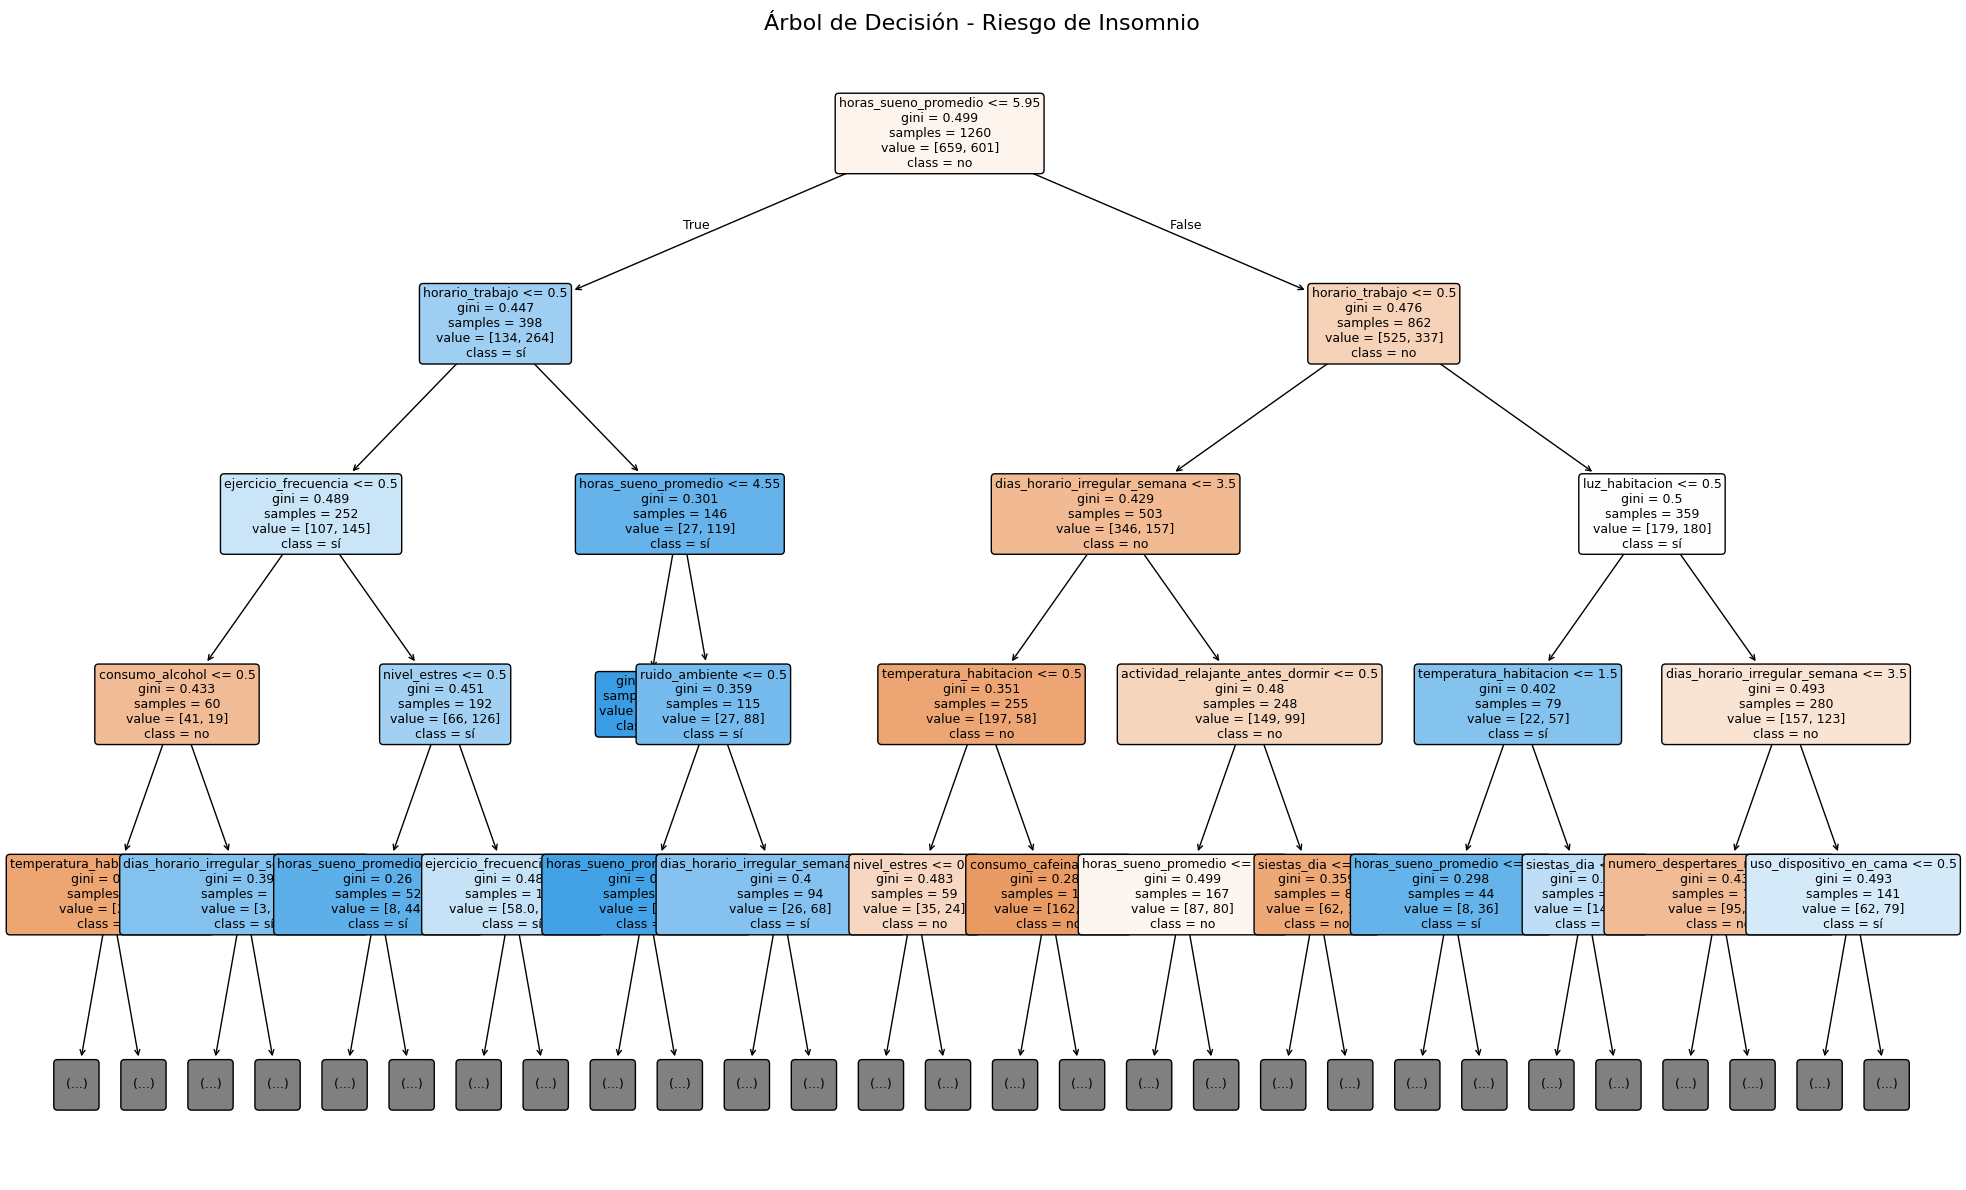

Evidencia guardada: arbol_sueno.png


In [5]:
# ============================================================
# PUNTO 3. EVIDENCIA DEL ENTRENAMIENTO
# ============================================================
print("\n" + "="*60)
print("PUNTO 3: EVIDENCIA DEL ENTRENAMIENTO")
print("="*60)
print(f"Profundidad del árbol: {arbol.tree_.max_depth}")
print(f"Número de nodos: {arbol.tree_.node_count}")
print(f"Número de hojas: {arbol.tree_.n_leaves}")

# Evidencia visual: árbol de decisión entrenado
plt.figure(figsize=(20, 12))
plot_tree(
    arbol, feature_names=X.columns, class_names=nombres_clases,
    filled=True, rounded=True, fontsize=9, max_depth=4
)
plt.title('Árbol de Decisión - Riesgo de Insomnio', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_sueno.png', dpi=300, bbox_inches='tight')
plt.show()
print("Evidencia guardada: arbol_sueno.png")


PUNTO 4: ANÁLISIS Y JUSTIFICACIÓN DE RESULTADOS
Precisión (Accuracy): 0.6259 (62.59%)

Reporte de clasificación:
              precision    recall  f1-score   support

          no       0.63      0.67      0.65       282
          sí       0.62      0.57      0.59       258

    accuracy                           0.63       540
   macro avg       0.62      0.62      0.62       540
weighted avg       0.63      0.63      0.62       540



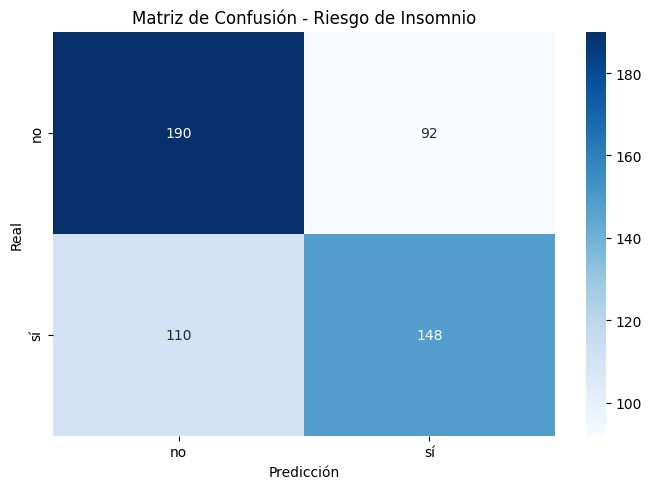

Evidencia guardada: matriz_confusion_sueno.png

Top 10 características más importantes:
                  Característica  Importancia
            horas_sueno_promedio     0.309033
                 horario_trabajo     0.157278
   dias_horario_irregular_semana     0.117155
            ejercicio_frecuencia     0.086803
                  luz_habitacion     0.060240
                    nivel_estres     0.057788
          temperatura_habitacion     0.053891
actividad_relajante_antes_dormir     0.040012
                 consumo_alcohol     0.027872
         uso_dispositivo_en_cama     0.023714


C:\Users\ANDY\AppData\Local\Temp\ipykernel_4304\1064905262.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias.head(10), y='Característica', x='Importancia', palette='mako')


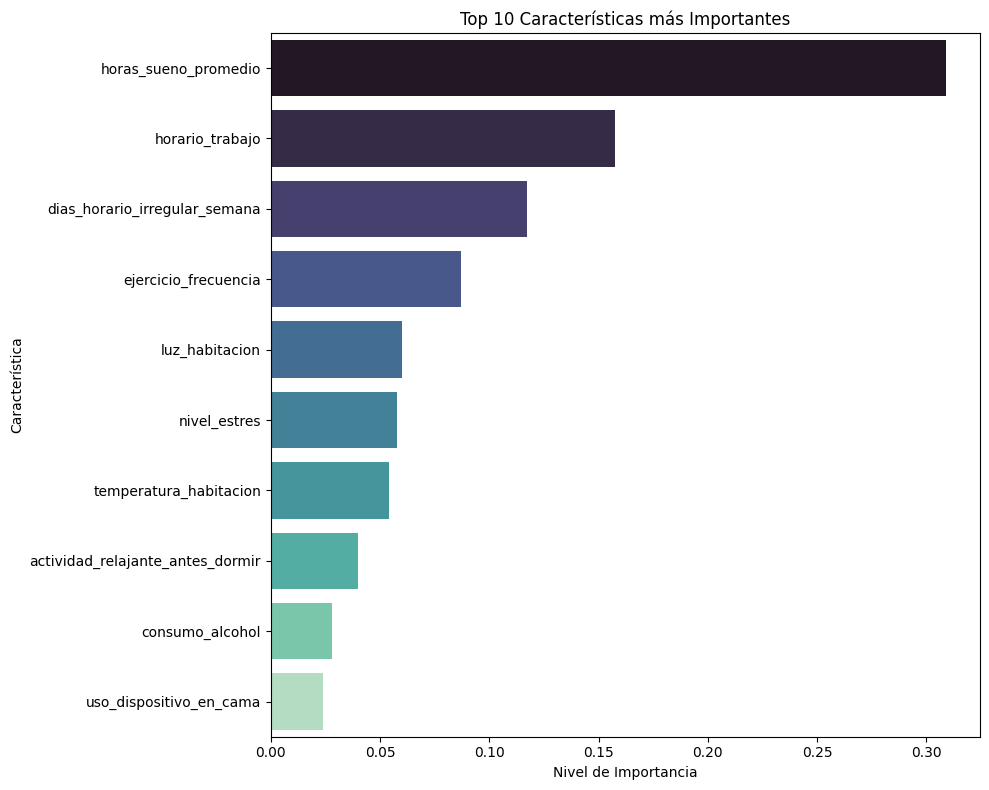

Evidencia guardada: importancias_sueno.png


In [6]:
# ============================================================
# PUNTO 4. ANÁLISIS Y JUSTIFICACIÓN DE RESULTADOS (con datos de prueba del split)
# ============================================================
print("\n" + "="*60)
print("PUNTO 4: ANÁLISIS Y JUSTIFICACIÓN DE RESULTADOS")
print("="*60)

y_pred = arbol.predict(X_test)
precision = accuracy_score(y_test, y_pred)

print(f"Precisión (Accuracy): {precision:.4f} ({precision*100:.2f}%)")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=nombres_clases))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Riesgo de Insomnio')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.savefig('matriz_confusion_sueno.png', dpi=300)
plt.show()
print("Evidencia guardada: matriz_confusion_sueno.png")

importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': arbol.feature_importances_
}).sort_values('Importancia', ascending=False)
print("\nTop 10 características más importantes:")
print(importancias.head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=importancias.head(10), y='Característica', x='Importancia', palette='mako')
plt.title('Top 10 Características más Importantes')
plt.xlabel('Nivel de Importancia')
plt.tight_layout()
plt.savefig('importancias_sueno.png', dpi=300)
plt.show()
print("Evidencia guardada: importancias_sueno.png")

In [7]:
# ============================================================
# PUNTO 5. EVIDENCIA CON DATOS DE PRUEBA NUEVOS (casos inventados)
# ============================================================
print("\n" + "="*60)
print("PUNTO 5: EVIDENCIA CON DATOS DE PRUEBA NUEVOS")
print("="*60)

# 3 personas nuevas, inventadas a mano (no forman parte del dataset de entrenamiento)
casos_nuevos = pd.DataFrame([
    {  # Caso A: hábitos saludables -> se espera riesgo bajo
        'horas_sueno_promedio': 8.0, 'consumo_cafeina': 'ninguna', 'uso_pantalla_antes_dormir': 'ninguno',
        'ejercicio_frecuencia': 'frecuente', 'nivel_estres': 'bajo', 'siestas_dia': 'ninguna',
        'ruido_ambiente': 'bajo', 'luz_habitacion': 'oscura', 'temperatura_habitacion': 'templada',
        'horario_trabajo': 'diurno', 'comida_pesada_antes_dormir': 'no', 'consumo_alcohol': 'no',
        'consumo_nicotina': 'no', 'uso_dispositivo_en_cama': 'no', 'actividad_relajante_antes_dormir': 'sí',
        'numero_despertares_noche': 0, 'dias_horario_irregular_semana': 0,
    },
    {  # Caso B: hábitos de riesgo alto -> se espera riesgo alto
        'horas_sueno_promedio': 4.5, 'consumo_cafeina': 'alta', 'uso_pantalla_antes_dormir': 'mucho',
        'ejercicio_frecuencia': 'nunca', 'nivel_estres': 'alto', 'siestas_dia': 'dos_o_mas',
        'ruido_ambiente': 'alto', 'luz_habitacion': 'iluminada', 'temperatura_habitacion': 'calurosa',
        'horario_trabajo': 'nocturno', 'comida_pesada_antes_dormir': 'sí', 'consumo_alcohol': 'sí',
        'consumo_nicotina': 'sí', 'uso_dispositivo_en_cama': 'sí', 'actividad_relajante_antes_dormir': 'no',
        'numero_despertares_noche': 4, 'dias_horario_irregular_semana': 6,
    },
    {  # Caso C: hábitos mixtos -> caso ambiguo
        'horas_sueno_promedio': 6.5, 'consumo_cafeina': 'media', 'uso_pantalla_antes_dormir': 'moderado',
        'ejercicio_frecuencia': 'ocasional', 'nivel_estres': 'medio', 'siestas_dia': 'una',
        'ruido_ambiente': 'medio', 'luz_habitacion': 'tenue', 'temperatura_habitacion': 'templada',
        'horario_trabajo': 'rotativo', 'comida_pesada_antes_dormir': 'no', 'consumo_alcohol': 'no',
        'consumo_nicotina': 'no', 'uso_dispositivo_en_cama': 'sí', 'actividad_relajante_antes_dormir': 'no',
        'numero_despertares_noche': 1, 'dias_horario_irregular_semana': 3,
    },
])

print("Casos de prueba (datos de entrada nuevos, no usados en el entrenamiento):")
print(casos_nuevos)

# Codificar los casos nuevos con los MISMOS encoders del entrenamiento
casos_encoded = casos_nuevos.copy()
for columna in columnas_categoricas:
    if columna == 'riesgo_insomnio':
        continue
    casos_encoded[columna] = encoders[columna].transform(casos_encoded[columna])

casos_encoded = casos_encoded[X.columns]  # mismo orden de columnas que en entrenamiento

predicciones = arbol.predict(casos_encoded)
probabilidades = arbol.predict_proba(casos_encoded)

print("\nResultados de clasificación para los 3 casos nuevos:")
for i, (pred, proba) in enumerate(zip(predicciones, probabilidades)):
    etiqueta = nombres_clases[pred]
    print(f"\nCaso {chr(65+i)}: Riesgo de insomnio = '{etiqueta}'")
    for j, clase in enumerate(nombres_clases):
        print(f"   Probabilidad '{clase}': {proba[j]:.2%}")


PUNTO 5: EVIDENCIA CON DATOS DE PRUEBA NUEVOS
Casos de prueba (datos de entrada nuevos, no usados en el entrenamiento):
   horas_sueno_promedio consumo_cafeina uso_pantalla_antes_dormir  \
0                   8.0         ninguna                   ninguno   
1                   4.5            alta                     mucho   
2                   6.5           media                  moderado   

  ejercicio_frecuencia nivel_estres siestas_dia ruido_ambiente luz_habitacion  \
0            frecuente         bajo     ninguna           bajo         oscura   
1                nunca         alto   dos_o_mas           alto      iluminada   
2            ocasional        medio         una          medio          tenue   

  temperatura_habitacion horario_trabajo comida_pesada_antes_dormir  \
0               templada          diurno                         no   
1               calurosa        nocturno                         sí   
2               templada        rotativo                        

In [8]:
# ============================================================
# PUNTO 6. ANÁLISIS Y JUSTIFICACIÓN DE RESULTADOS (casos nuevos)
# ============================================================
print("\n" + "="*60)
print("PUNTO 6: ANÁLISIS DE LOS CASOS DE PRUEBA")
print("="*60)
print("Ver análisis narrativo en el documento PDF: se espera que el Caso A")
print("(hábitos saludables) sea clasificado con bajo riesgo, el Caso B")
print("(hábitos de riesgo) con alto riesgo, y el Caso C (hábitos mixtos)")
print("sea el más incierto, con probabilidades más cercanas al 50/50.")


PUNTO 6: ANÁLISIS DE LOS CASOS DE PRUEBA
Ver análisis narrativo en el documento PDF: se espera que el Caso A
(hábitos saludables) sea clasificado con bajo riesgo, el Caso B
(hábitos de riesgo) con alto riesgo, y el Caso C (hábitos mixtos)
sea el más incierto, con probabilidades más cercanas al 50/50.



PUNTO 7: PROCESAMIENTO PCA


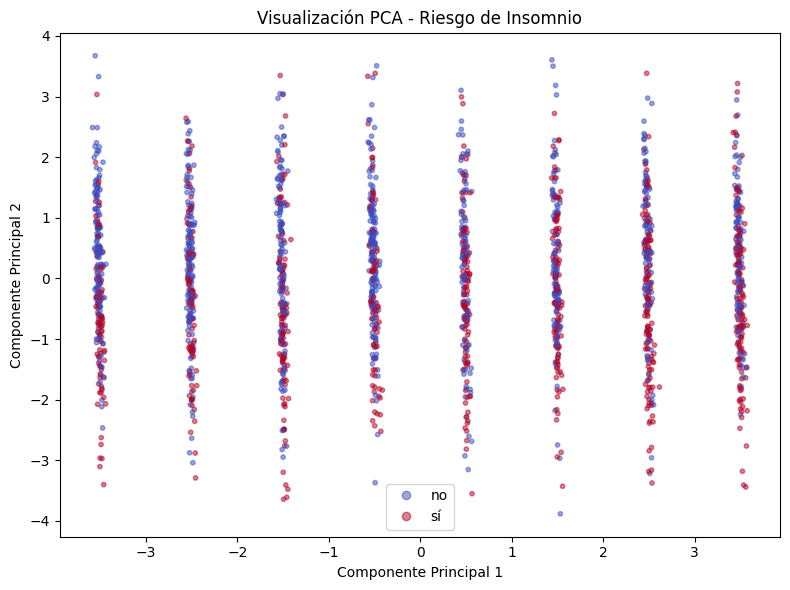

Evidencia guardada: pca_sueno.png

Varianza explicada por cada componente: [0.33791394 0.10299697]
Varianza total explicada por ambos componentes: 44.09%

PROCESO COMPLETO FINALIZADO


In [9]:
# ============================================================
# PUNTO 7. GRÁFICAS - PROCESAMIENTO PCA
# ============================================================
print("\n" + "="*60)
print("PUNTO 7: PROCESAMIENTO PCA")
print("="*60)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.5, s=10)
plt.title('Visualización PCA - Riesgo de Insomnio')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], labels=nombres_clases)
plt.tight_layout()
plt.savefig('pca_sueno.png', dpi=300)
plt.show()
print("Evidencia guardada: pca_sueno.png")

varianza_explicada = pca.explained_variance_ratio_
print(f"\nVarianza explicada por cada componente: {varianza_explicada}")
print(f"Varianza total explicada por ambos componentes: {sum(varianza_explicada):.2%}")

print("\n" + "="*60)
print("PROCESO COMPLETO FINALIZADO")
print("="*60)